# Allen data
- See [Allen Github](https://github.com/AllenInstitute/abc_atlas_access/blob/main/notebooks/getting_started.ipynb)
- Expression matrix format: [anndata h5ad format](https://anndata.readthedocs.io/en/latest/)
- Note: WMB_10x = single cell profiles
- Macosko dataset contains millions of seq nuclei from broad

In conda/mamba environment ran:
`pip install "abc_atlas_access[notebooks] @ git+https://github.com/alleninstitute/abc_atlas_access.git"`

In [1]:
# load Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scanpy as sc

In [2]:
# import necessary functions
from pathlib import Path
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache
from abc_atlas_access.abc_atlas_cache.anndata_utils import get_gene_data
from anndata import AnnData
from anndata import read_h5ad


# Download Allen data

In [3]:
# set-up AbcProjectCache object
download_base = Path('../../data/abc_atlas')
abc_cache = AbcProjectCache.from_cache_dir(download_base)
# abc_cache = AbcProjectCache.from_local_cache(download_base)

# abc_cache.current_manifest # lists version of cache

**NOTE:** at time of writine, current released used was: `releases/20251031/manifest.json`

Can load same release by using: `abc_cache.load_manifest('releases/20251031/manifest.json')`

In [4]:
# load latest manifest
abc_cache.load_latest_manifest()

abc_cache.list_directories

['ASAP-PMDBS-10X',
 'ASAP-PMDBS-taxonomy',
 'Allen-CCF-2020',
 'Consensus-WMB-AIBS-10X',
 'Consensus-WMB-Macosko-10X',
 'Consensus-WMB-integrated-taxonomy',
 'HMBA-10xMultiome-BG',
 'HMBA-10xMultiome-BG-Aligned',
 'HMBA-BG-taxonomy-CCN20250428',
 'HMBA-MERSCOPE-H22.30.001-BG',
 'HMBA-MERSCOPE-QM23.50.001-BG',
 'HMBA-Xenium-CJ23.56.004-BG',
 'MERFISH-C57BL6J-638850',
 'MERFISH-C57BL6J-638850-CCF',
 'MERFISH-C57BL6J-638850-imputed',
 'MERFISH-C57BL6J-638850-sections',
 'SEAAD-taxonomy',
 'WHB-10Xv3',
 'WHB-taxonomy',
 'WMB-10X',
 'WMB-10XMulti',
 'WMB-10Xv2',
 'WMB-10Xv3',
 'WMB-neighborhoods',
 'WMB-taxonomy',
 'Zeng-Aging-Mouse-10Xv3',
 'Zeng-Aging-Mouse-WMB-taxonomy',
 'Zhuang-ABCA-1',
 'Zhuang-ABCA-1-CCF',
 'Zhuang-ABCA-2',
 'Zhuang-ABCA-2-CCF',
 'Zhuang-ABCA-3',
 'Zhuang-ABCA-3-CCF',
 'Zhuang-ABCA-4',
 'Zhuang-ABCA-4-CCF',
 'mmc-gene-mapper']

In [10]:
abc_cache.list_expression_matrix_files('Consensus-WMB-Macosko-10X')


['Macosko-10X-CB/log2',
 'Macosko-10X-CB/raw',
 'Macosko-10X-HPF/log2',
 'Macosko-10X-HPF/raw',
 'Macosko-10X-HY/log2',
 'Macosko-10X-HY/raw',
 'Macosko-10X-Isocortex/log2',
 'Macosko-10X-Isocortex/raw',
 'Macosko-10X-MB/log2',
 'Macosko-10X-MB/raw',
 'Macosko-10X-MY-Pons-BS/log2',
 'Macosko-10X-MY-Pons-BS/raw',
 'Macosko-10X-OLF/log2',
 'Macosko-10X-OLF/raw',
 'Macosko-10X-PAL/log2',
 'Macosko-10X-PAL/raw',
 'Macosko-10X-STR/log2',
 'Macosko-10X-STR/raw',
 'Macosko-10X-TH/log2',
 'Macosko-10X-TH/raw']

In [11]:
# one metadata for WHB-10x (not for individual 10xV#)
print(abc_cache.list_metadata_files('Consensus-WMB-Macosko-10X'))

['cell_metadata', 'donor', 'example_gene_expression', 'gene', 'library', 'value_sets']


In [12]:
# download cell metadata to get labels of cells in relevant ROIs
cells = abc_cache.get_metadata_dataframe(
    directory='Consensus-WMB-Macosko-10X',
    file_name='cell_metadata'
)

# rois = abc_cache.get_metadata_dataframe(
#     directory='WMB-10X',
#     file_name='region_of_interest_metadata'
# )

# cell_clusters = abc_cache.get_metadata_dataframe(
#     directory='WMB-10X',
#     file_name='cell_metadata_with_cluster_annotation'
# )


cell_metadata.csv: 100%|██████████| 506M/506M [05:33<00:00, 1.52MMB/s]    


In [15]:
cells["feature_matrix_label"].value_counts()

feature_matrix_label
Macosko-10X-Isocortex     745851
Macosko-10X-MY-Pons-BS    651031
Macosko-10X-MB            613087
Macosko-10X-CB            464681
Macosko-10X-TH            333381
Macosko-10X-HPF           328285
Macosko-10X-PAL           205374
Macosko-10X-OLF           159574
Macosko-10X-STR           144483
Macosko-10X-HY             90534
Name: count, dtype: int64

In [ ]:
# Download gene metadata
genes = abc_cache.get_metadata_dataframe(
    directory="Consensus-WMB-Macosko-10X",
    file_name='gene'
)

In [ ]:
# subset cells to MOp
mop_cells = cells[cells["region_of_interest_acronym"]=="MOp"]
mop_cells_10Xv3 = mop_cells[mop_cells["dataset_label"]=="WMB-10Xv3"]
print(mop_cells_10Xv3.shape)

In [ ]:
mop_cells_10Xv3 = mop_cells_10Xv3.set_index("cell_label")
genes = genes.set_index("gene_identifier")

In [ ]:
# download expression file
abc_cache.get_file_path(directory="WMB-10Xv3", file_name="WMB-10Xv3-Isocortex-1/log2") # 11 Gb
abc_cache.get_file_path(directory="WMB-10Xv3", file_name="WMB-10Xv3-Isocortex-2/log2") # 11 Gb

In [ ]:
genes_list = genes.loc[:,"gene_symbol"].to_list()
print(len(genes_list))
genes_list[:10]

In [ ]:
# extract gene expression
expr = get_gene_data(
    abc_atlas_cache=abc_cache,
    all_cells=mop_cells_10Xv3,
    all_genes=genes,
    selected_genes=genes_list
)
expr

# gene_data = get_gene_data(
#     abc_atlas_cache=abc_cache,
#     all_cells=nonneuron_cells,
#     all_genes=gene,
#     selected_genes=gene_names
# )
# gene_data[pd.notna(gene_data[gene_data.columns[0]])]

In [ ]:
# create anndata object

var_genes = genes.reset_index().set_index("gene_symbol")
adata = AnnData(expr, obs=mop_cells_10Xv3, var=var_genes)


# save adata
adata_file = "/Users/eisko/data/custom_saves/WMB-10xV3-MOp.h5ad"
adata.write(adata_file)

# quality control


In [ ]:
# read in adata file
adata_file = "/Users/eisko/data/custom_saves/WMB-10xV3-MOp.h5ad"
adata = read_h5ad(adata_file, backed="r") # prevents from loading full file into RAM, more stable for analysis

/Users/eisko/miniforge3/envs/snRNAseq/lib/python3.14/site-packages/anndata/_core/anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [6]:

# Mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("mt-")
# Ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("Rps", "Rpl"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("Hb[^spe]")


In [7]:
# display genes
print(adata.var_names[adata.var["mt"]])
print(f"{sum(adata.var["mt"])}/{adata.n_vars} are mitochondrial genes\n")
print(adata.var_names[adata.var["ribo"]])
print(f"{sum(adata.var["ribo"])}/{adata.n_vars} are ribosomal genes\n")
print(adata.var_names[adata.var["hb"]])
print(f"{sum(adata.var["hb"])}/{adata.n_vars} are hemoglobin genes\n")


Index(['mt-Nd1', 'mt-Nd2', 'mt-Co1', 'mt-Co2', 'mt-Atp8', 'mt-Atp6', 'mt-Co3',
       'mt-Nd3', 'mt-Nd4l', 'mt-Nd4', 'mt-Nd5', 'mt-Nd6', 'mt-Cytb'],
      dtype='object', name='gene_symbol')
13/32285 are mitochondrial genes

Index(['Rpl7', 'Rpl31', 'Rpl37a', 'Rps6kc1', 'Rpl7a', 'Rpl12', 'Rpl35',
       'Rps21', 'Rpl22l1', 'Rps3a1',
       ...
       'Rpl17', 'Rps6kb2', 'Rps6ka4', 'Rpl9-ps6', 'Rpl39', 'Rpl10', 'Rps4x',
       'Rps6ka6', 'Rpl36a', 'Rps6ka3'],
      dtype='object', name='gene_symbol', length=101)
101/32285 are ribosomal genes

Index(['Hbb-bt', 'Hbb-bs', 'Hbb-bh2', 'Hbb-bh1', 'Hbb-y', 'Hba-x', 'Hba-a1',
       'Hbq1b', 'Hba-a2', 'Hbq1a'],
      dtype='object', name='gene_symbol')
10/32285 are hemoglobin genes



In [14]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"],
                           inplace=True, log1p=True)
adata.var_keys

<bound method AnnData.var_keys of AnnData object with n_obs × n_vars = 124501 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'abc_sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_identifier', 'name', 'mapped_ncbi_identifier', 'comment', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'>

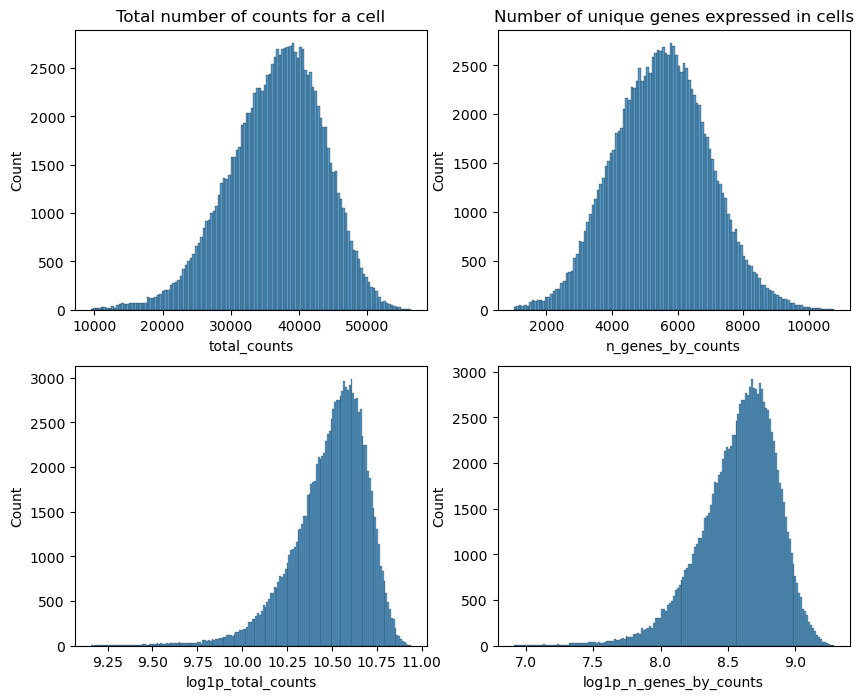

In [15]:
fig, axs = plt.subplots(2,2, figsize=(10,8))

sns.histplot(adata.obs["total_counts"], ax=axs[0,0])
axs[0,0].set_title("Total number of counts for a cell")

sns.histplot(adata.obs["n_genes_by_counts"], ax=axs[0,1])
axs[0,1].set_title("Number of unique genes expressed in cells")

sns.histplot(adata.obs["log1p_total_counts"], ax=axs[1,0])

sns.histplot(adata.obs["log1p_n_genes_by_counts"], ax=axs[1,1])

plt.show()

In [18]:
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 124501 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'abc_sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_identifier', 'name', 'mapped_ncbi_identifier', 'comment', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

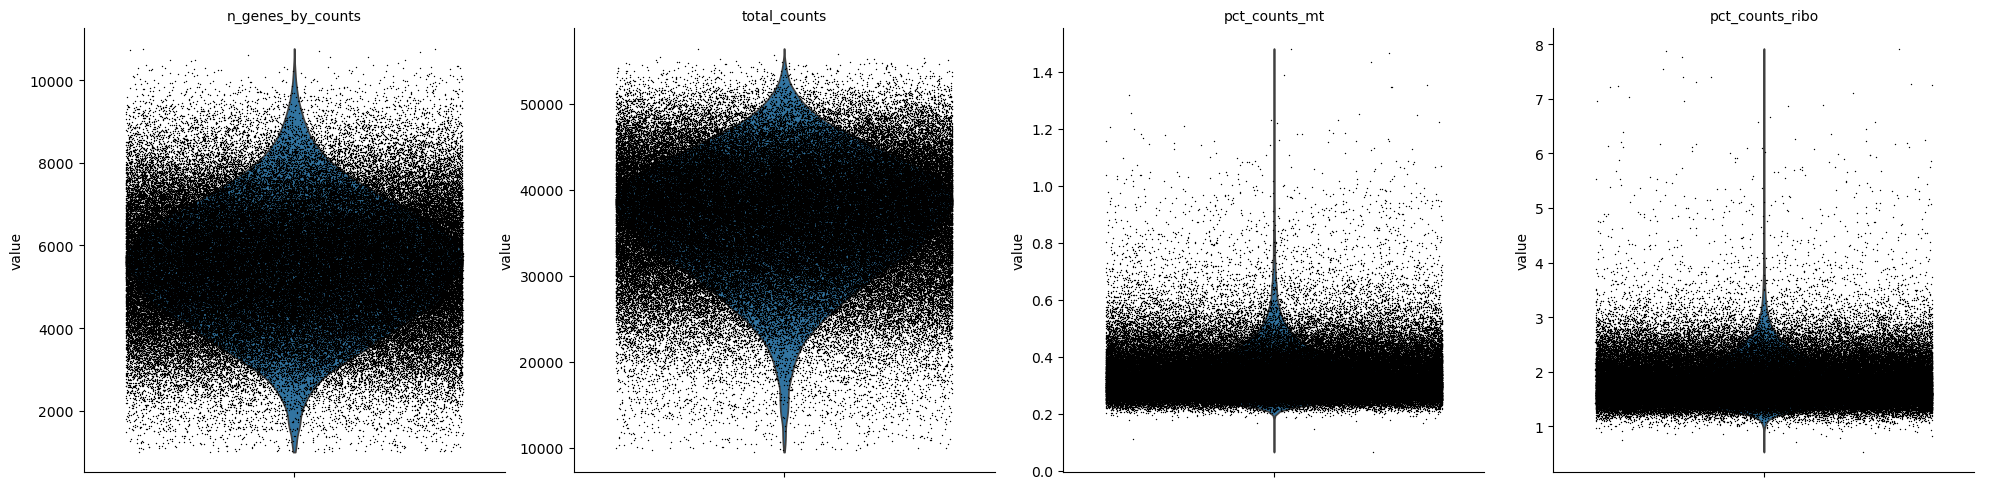

In [19]:
# scanpy, plotting, violin
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"],
    jitter=0.4,
    multi_panel=True,
)